In [21]:
import matplotlib.pyplot as plt
import numpy as np

from utils.fit_data import ResonanceFitData
from utils.pendulums_data import PendulumsData, prepare_data
from utils.plotting import add_resonance_plot_labels, plot_all, plot_each, save_plot

In [22]:
cols = ["mass A", "mass B", "mass C", "mass D"]
labels = ["50 cm", "65 cm", "40 cm", "50 cm (driver)"]
lengths = np.array([0.5, 0.65, 0.4, 0.5])
L_d = 0.5

In [23]:
pendulums_data = PendulumsData(
    cols=cols,
    labels=labels,
    lengths=lengths,
    data=prepare_data("../data/session-2/data2.csv", cols),
)
pendulums_data.preprocess_offsets()
pendulums_data.normalize()

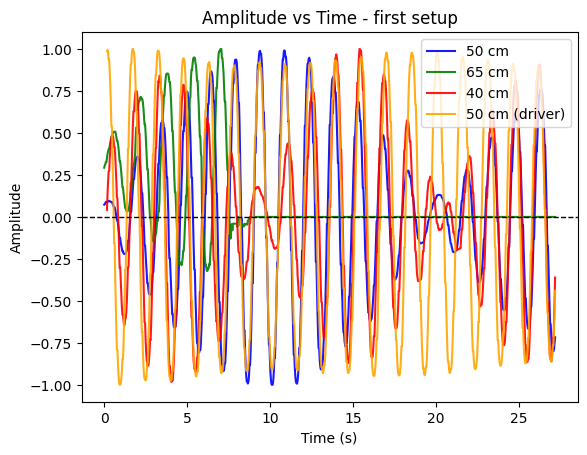

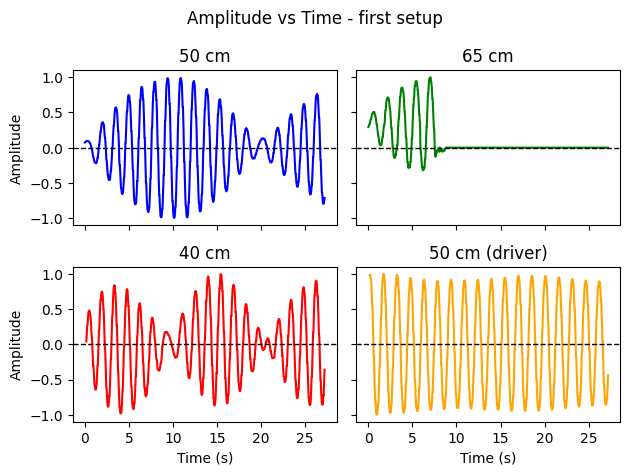

In [24]:
# base plots
plot_all(
    pendulums_data,
    cols=cols,
    title="Amplitude vs Time - first setup",
)
save_plot("session-2/amp-vs-time-first-all.pdf")
plt.show()

plot_each(pendulums_data, title="Amplitude vs Time - first setup")
save_plot("session-2/amp-vs-time-first-each.pdf")
plt.show()

In [25]:
pendulums_data.drop_cols(["mass B", "mass D"])
pendulums_data.data.dropna(inplace=True)

In [26]:
resonance_data = ResonanceFitData(L_d, pendulums_data)
resonance_data.fit()

50 cm: peaks=2; mean=0.996
40 cm: peaks=2; mean=0.991
Gamma: 11.3694 ± 0.0019


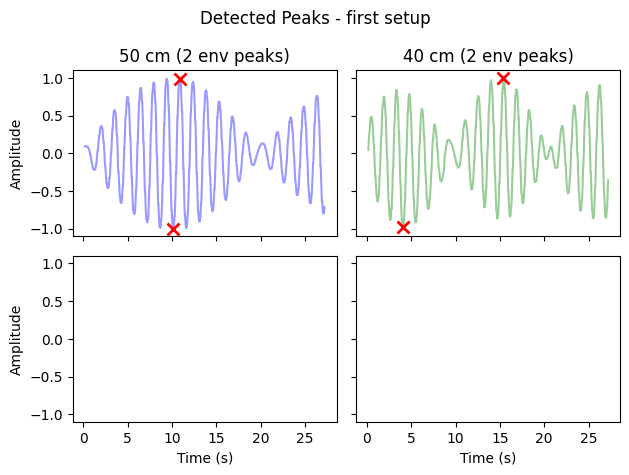

In [27]:
gamma, gamma_err = resonance_data.gamma, resonance_data.gamma_err
print(resonance_data.envelope_data)
print(f"Gamma: {gamma:.4f} ± {gamma_err:.4f}")

resonance_data.plot_detected_peaks(title="Detected Peaks - first setup")
save_plot("session-2/detected-peaks-first.pdf")
plt.show()

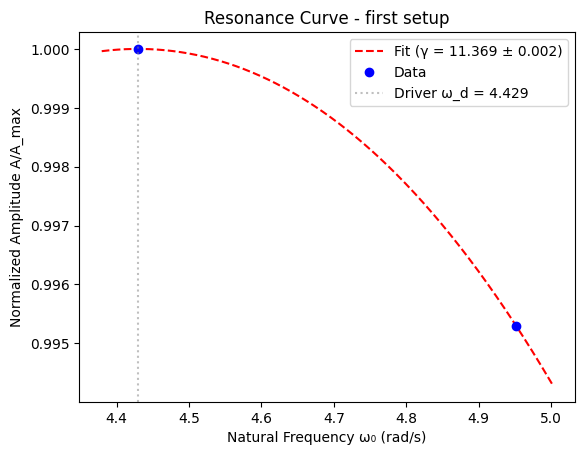

In [28]:
resonance_data.plot_resonance_curve("blue", "red")
add_resonance_plot_labels(title="Resonance Curve - first setup")
save_plot("session-2/resonance-curve-first.pdf")